# SQuaD - Question Answering

##### Model A: Custom BiLSTM + Attention
##### Model B: Fine-Tuned DistilBERT

###### Train 1.1. Dataset URL => https://raw.githubusercontent.com/rajpurkar/SQuAD-explorer/refs/heads/master/dataset/train-v1.1.json
###### Dev   1.1. Dataset URL => https://raw.githubusercontent.com/rajpurkar/SQuAD-explorer/refs/heads/master/dataset/dev-v1.1.json


In [1]:
## JSON Data Structure
# data => title
#         paragraphs => context
#                       qas     => answers  =>  answer_start
#                                               text
#                               => question
#                               => id

In [1]:
import pandas as pd
from parser import parser, map_char_to_token, clean_dev_data, map_answer_to_positions, filter_spans
from parser.tokenizer import tokenize
from embedding.vocabulary import build_vocabulary, apply_vocabulary, pad_sequences, make_mask
from embedding import Embeddings
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from evaluate import get_score, plot_graph
from models import BiDAFAttention
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np, gc
import random
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, TrainingArguments, Trainer
import torch
from torch.utils.data import Dataset

from dotenv import load_dotenv

load_dotenv()


I0000 00:00:1786681833.427996    3637 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786681833.857238    3637 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786681835.471224    3637 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


True

### Train Dataset Preprocessing

In [2]:
train_df = pd.read_json("./dataset/train-v1.1.json")

print(f"Initial structure:\n {train_df.head()}")

# Parse Train Data
train_df = parser(train_df["data"])

## COMMENT THIS BELOW 2 LINE OF CODES ONCE TRAINING IS DONE
# Shuffle and sample 10k rows for training
# train_df = train_df.sample(n=30000, random_state=42).reset_index(drop=True)

print(f"\nParsed Data:\n {train_df.head().to_string()}")
print(f"\nCheck Data Type and Non-Null Counts:\n {train_df.info()}")

# change data type
cols = ["title", "context"]
for col in cols:
    train_df[col].astype("category")

print(f"\nData types:\n {train_df.dtypes}")

print(f"\nMissing Values:\n {train_df.isna().sum()}")
print(f"\nDuplicates Rows:\n {train_df.duplicated().sum()}")


Initial structure:
                                                 data  version
0  {'title': 'University_of_Notre_Dame', 'paragra...      1.1
1  {'title': 'Beyoncé', 'paragraphs': [{'context'...      1.1
2  {'title': 'Montana', 'paragraphs': [{'context'...      1.1
3  {'title': 'Genocide', 'paragraphs': [{'context...      1.1
4  {'title': 'Antibiotics', 'paragraphs': [{'cont...      1.1

Parsed Data:
                       title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### Dev Dataset Preprocessing

In [3]:
dev_df = pd.read_json("./dataset/dev-v1.1.json")

# Parse Dev Data
dev_df = parser(dev_df["data"])

## COMMENT THIS BELOW 2 LINE OF CODES ONCE TRAINING IS DONE
# Shuffle and sample 1.5k rows for validation
# dev_df = dev_df.sample(n=3000, random_state=42).reset_index(drop=True)

# Duplication is expected, since the answer's have been collected
# by humans, however the answer_start might differ in some cases.
print(f"\nDev Dataset Look:\n {dev_df.head().to_string()}")

print(f"\nCheck Data Type and Non-Null Counts:\n {dev_df.info()}")

# change data type
for col in cols:
    dev_df[col].astype("category")

print(f"\nData types:\n {dev_df.dtypes}")

print(f"\nMissing Values:\n {dev_df.isna().sum()}")
print(f"\nDuplicates Rows:\n {dev_df.duplicated().sum()}")

##
# We do not remove duplicates yet, firstly this is a SquaD dataset where
# validation data has been answered by multiple human to same question.
# Therefore, duplication is expected.
# However, we do need to remove identical and group them for EM/F1 scoring.
# For that we will do later after mapping char to token, to keep it simple.
##


Dev Dataset Look:
            title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  context               question_id                                              question  answer_start  answer_end               text
0  super_bowl_50  super bowl 50 was an american football game

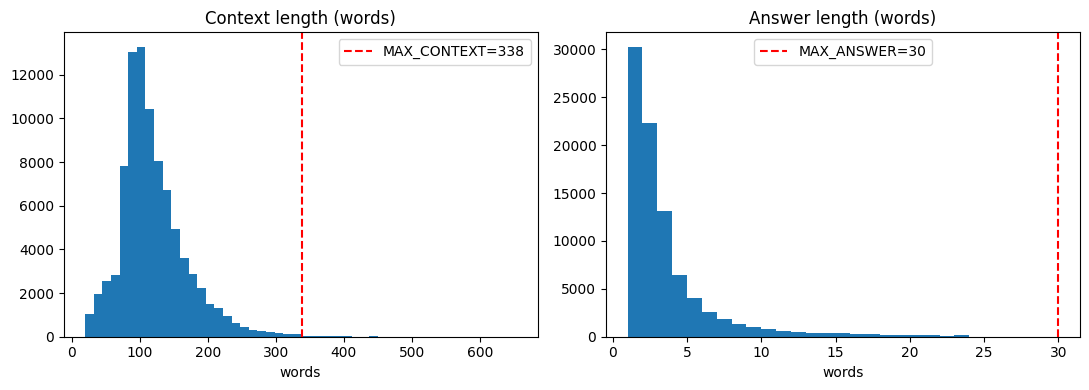

In [4]:
# EDA
ctx_len = train_df["context"].str.split().str.len()
ans_len = train_df["text"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ctx_len, bins=50); ax[0].axvline(338, color="r", ls="--", label="MAX_CONTEXT=338")
ax[0].set_title("Context length (words)"); ax[0].set_xlabel("words"); ax[0].legend()
ax[1].hist(ans_len, bins=range(1, 25)); ax[1].axvline(30, color="r", ls="--", label="MAX_ANSWER=30")
ax[1].set_title("Answer length (words)"); ax[1].set_xlabel("words"); ax[1].legend()
plt.tight_layout(); plt.show()

### Model A: Train Data
### Tokenization, Vocabulary, Embeddings

In [5]:
# comma, special character etc are not removed since this is a QA-SQuaD dataset,
# and removing any character will cause errors with the answer_start offset.
# stemming or lemmatization is also not required.

at_df = tokenize(train_df.copy())

# Map Char to Token => after tokenization we need to map
# answer_start and answer_end offset to token index
at_df["start_token"], at_df["end_token"] = zip(*at_df.apply(map_char_to_token, axis=1))


# since for SQuaD, test data is kept hidden therefore we will split train data into val and train.
# we are splitting here, since there is no leakage. A minor leak may occur in vocabular
# but that is universally accepted for SQuaD. Since for this dataset, real leak is the
# overlap of article/context. Therefore, we find unique titles and then split based on that.
titles = train_df["title"].unique().to_numpy()  # type: ignore
train_titles, val_titles = train_test_split(titles, test_size=0.1, random_state=42)
av_df = at_df[at_df["title"].isin(val_titles)].reset_index(drop=True)
at_df = at_df[at_df["title"].isin(train_titles)].reset_index(drop=True)


# BUILD VOCABULARY
word2idx, idx2word = build_vocabulary(at_df)

# APPLY VOCABULARY TO TRAIND DF
at_df = apply_vocabulary(at_df, word2idx)

# GloVe Embeddings
glove = Embeddings(path='./embedding/glove.2024.11b.100d.txt')
t_embeddings = glove.generate_embedding(word2idx=word2idx)

# Padding
# instead of using max(len(...context_ids)), it's better to see the best appropriate length
# this saves storage later when doing C_LEN*BATCH*HIDDEN 
lengths = at_df["context_ids"].apply(len)
print(f"Likley length for CONTEXT_LENGTH:\n {lengths.quantile([0.9, 0.95, 0.99, 1.0])}")

MAX_CONTEXT_LENGTH = 338 #max(len(x) for x in at_df["context_ids"])
MAX_QUESTION_LENGTH = max(len(x) for x in at_df["question_ids"])

at_df["context_ids_pad"] = pad_sequences(at_df["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"])
at_df["question_ids_pad"] = pad_sequences(at_df["question_ids"], MAX_QUESTION_LENGTH,word2idx["<PAD>"])

# Attention/Padding MASK, now that we have padded sequence, we create mask as guide
# So model knows that 1 is where it needs to pay attention and ignore 0's.
at_df["context_mask"] = make_mask(at_df["context_ids"], MAX_CONTEXT_LENGTH)
at_df["question_mask"] = make_mask(at_df["question_ids"], MAX_QUESTION_LENGTH)

# clean data to avoid crashing during training 
# keep only valid text spans.
at_df = filter_spans(at_df, MAX_CONTEXT_LENGTH)


## DO SAME FOR VAL SPLIT
av_df = apply_vocabulary(av_df, word2idx)
av_df["context_ids_pad"] = pad_sequences(av_df["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"])
av_df["question_ids_pad"] = pad_sequences(av_df["question_ids"], MAX_QUESTION_LENGTH,word2idx["<PAD>"])
av_df["context_mask"] = make_mask(av_df["context_ids"], MAX_CONTEXT_LENGTH)
av_df["question_mask"] = make_mask(av_df["question_ids"], MAX_QUESTION_LENGTH)
av_df = filter_spans(av_df, MAX_CONTEXT_LENGTH)

# Verify data
at_df.head()

Found 69887/75720 words in GloVe
Likley length for CONTEXT_LENGTH:
 0.90    220.0
0.95    254.0
0.99    336.0
1.00    854.0
Name: context_ids, dtype: float64


,title,context,question_id,question,answer_start,answer_end,text,context_tokens,context_offsets,question_tokens,start_token,end_token,context_ids,question_ids,context_ids_pad,question_ids_pad,context_mask,question_mask
0,university_of_notre_dame,"architecturally, the school has a catholic cha...",5733be284776f41900661182,to whom did the virgin mary allegedly appear i...,515,541,saint bernadette soubirous,"[architecturally, ,, the, school, has, a, cath...","[(0, 15), (15, 16), (17, 20), (21, 27), (28, 3...","[to, whom, did, the, virgin, mary, allegedly, ...",103,105,"[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[8, 831, 55, 2, 2654, 791, 6136, 1423, 7, 5819...","[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[8, 831, 55, 2, 2654, 791, 6136, 1423, 7, 5819...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ..."
1,university_of_notre_dame,"architecturally, the school has a catholic cha...",5733be284776f4190066117f,what is in front of the notre dame main building?,188,213,a copper statue of christ,"[architecturally, ,, the, school, has, a, cath...","[(0, 15), (15, 16), (17, 20), (21, 27), (28, 3...","[what, is, in, front, of, the, notre, dame, ma...",38,42,"[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 12, 7, 1074, 5, 2, 1732, 1631, 299, 348, 18]","[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 12, 7, 1074, 5, 2, 1732, 1631, 299, 348, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
2,university_of_notre_dame,"architecturally, the school has a catholic cha...",5733be284776f41900661180,the basilica of the sacred heart at notre dame...,279,296,the main building,"[architecturally, ,, the, school, has, a, cath...","[(0, 15), (15, 16), (17, 20), (21, 27), (28, 3...","[the, basilica, of, the, sacred, heart, at, no...",58,60,"[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[2, 6878, 5, 2, 3440, 1368, 30, 1732, 1631, 12...","[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[2, 6878, 5, 2, 3440, 1368, 30, 1732, 1631, 12...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,university_of_notre_dame,"architecturally, the school has a catholic cha...",5733be284776f41900661181,what is the grotto at notre dame?,381,420,a marian place of prayer and reflection,"[architecturally, ,, the, school, has, a, cath...","[(0, 15), (15, 16), (17, 20), (21, 27), (28, 3...","[what, is, the, grotto, at, notre, dame, ?]",77,83,"[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 12, 2, 19747, 30, 1732, 1631, 18]","[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 12, 2, 19747, 30, 1732, 1631, 18, 0, 0, 0...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ..."
4,university_of_notre_dame,"architecturally, the school has a catholic cha...",5733be284776f4190066117e,what sits on top of the main building at notre...,92,126,a golden statue of the virgin mary,"[architecturally, ,, the, school, has, a, cath...","[(0, 15), (15, 16), (17, 20), (21, 27), (28, 3...","[what, sits, on, top, of, the, main, building,...",18,24,"[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 10516, 24, 346, 5, 2, 299, 348, 30, 1732,...","[12606, 3, 2, 166, 38, 9, 615, 826, 4, 5744, 2...","[26, 10516, 24, 346, 5, 2, 299, 348, 30, 1732,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..."


#### SANITY CHECKS

In [7]:
for _ in range(5):
    i = random.randint(0, len(at_df) - 1)

    predicted = " ".join(
        at_df.iloc[i]["context_tokens"][
            at_df.iloc[i]["start_token"]:
            at_df.iloc[i]["end_token"] + 1
        ]
    )

    print(f"Sample {i}")
    print("Predicted   :", predicted)
    print("Ground Truth:", at_df.iloc[i]["text"])
    print("-" * 40)


Sample 79782
Predicted   : 4 , 900 – 9 , 800
Ground Truth: 4,900–9,800
----------------------------------------
Sample 6184
Predicted   : the force that drives saṃsāra
Ground Truth: the force that drives saṃsāra
----------------------------------------
Sample 11659
Predicted   : new mexico
Ground Truth: new mexico
----------------------------------------
Sample 75185
Predicted   : english
Ground Truth: english
----------------------------------------
Sample 66603
Predicted   : 160 km / h
Ground Truth: 160 km/h
----------------------------------------


### Model A: Dev Data
### Tokenization, Vocabulary, Embeddings

In [9]:
# comma, special character etc are not removed since this is a QA-SQuaD dataset,
# and removing any character will cause errors with the answer_start offset.
# stemming or lemmatization is also not required.

ad_df = tokenize(dev_df.copy())

# Map Char to Token => after tokenization we need to map
# answer_start and answer_end offset to token index
ad_df["start_token"], ad_df["end_token"] = zip(*ad_df.apply(map_char_to_token, axis=1))

# Remove duplicates and group for later EM/F1 Evaluation
ad_df_grouped = clean_dev_data(ad_df.copy())

# APPLY Vocab IDs based on tokens
ad_df = apply_vocabulary(ad_df, word2idx)

# GloVe Embeddings
# glove = Embeddings(path='./embedding/glove.2024.11b.100d.txt')
# d_embeddings = glove.generate_embedding(word2idx=word2idx)

# Padding
ad_df["context_ids_pad"] = pad_sequences(ad_df["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"])
ad_df["question_ids_pad"] = pad_sequences(ad_df["question_ids"], MAX_QUESTION_LENGTH,word2idx["<PAD>"])

# MASK
ad_df["context_mask"] = make_mask(ad_df["context_ids"], MAX_CONTEXT_LENGTH)
ad_df["question_mask"] = make_mask(ad_df["question_ids"], MAX_QUESTION_LENGTH)

ad_df = filter_spans(ad_df, MAX_CONTEXT_LENGTH)

# Verify data
ad_df.head()

,title,context,question_id,question,answer_start,answer_end,text,context_tokens,context_offsets,question_tokens,start_token,end_token,context_ids,question_ids,context_ids_pad,question_ids_pad,context_mask,question_mask
0,super_bowl_50,super bowl 50 was an american football game to...,56be4db0acb8001400a502ec,which nfl team represented the afc at super bo...,177,191,denver broncos,"[super, bowl, 50, was, an, american, football,...","[(0, 5), (6, 10), (11, 13), (14, 17), (18, 20)...","[which, nfl, team, represented, the, afc, at, ...",33,34,"[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
1,super_bowl_50,super bowl 50 was an american football game to...,56be4db0acb8001400a502ec,which nfl team represented the afc at super bo...,177,191,denver broncos,"[super, bowl, 50, was, an, american, football,...","[(0, 5), (6, 10), (11, 13), (14, 17), (18, 20)...","[which, nfl, team, represented, the, afc, at, ...",33,34,"[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
2,super_bowl_50,super bowl 50 was an american football game to...,56be4db0acb8001400a502ec,which nfl team represented the afc at super bo...,177,191,denver broncos,"[super, bowl, 50, was, an, american, football,...","[(0, 5), (6, 10), (11, 13), (14, 17), (18, 20)...","[which, nfl, team, represented, the, afc, at, ...",33,34,"[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 42161, 30, 1778, 3275...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
3,super_bowl_50,super bowl 50 was an american football game to...,56be4db0acb8001400a502ed,which nfl team represented the nfc at super bo...,249,266,carolina panthers,"[super, bowl, 50, was, an, american, football,...","[(0, 5), (6, 10), (11, 13), (14, 17), (18, 20)...","[which, nfl, team, represented, the, nfc, at, ...",44,45,"[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 40910, 30, 1778, 3275...","[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 40910, 30, 1778, 3275...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
4,super_bowl_50,super bowl 50 was an american football game to...,56be4db0acb8001400a502ed,which nfl team represented the nfc at super bo...,249,266,carolina panthers,"[super, bowl, 50, was, an, american, football,...","[(0, 5), (6, 10), (11, 13), (14, 17), (18, 20)...","[which, nfl, team, represented, the, nfc, at, ...",44,45,"[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 40910, 30, 1778, 3275...","[1778, 3275, 695, 13, 33, 116, 510, 409, 8, 27...","[28, 9335, 438, 1516, 2, 40910, 30, 1778, 3275...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."


#### SANITY CHECKS

In [10]:
print("Context shape:", len(ad_df["context_ids_pad"][0]))
print("Question shape:", len(ad_df["question_ids_pad"][0]))
print("Context mask shape:", len(ad_df["context_mask"][0]))
print("Start token:", ad_df.iloc[0]["start_token"])
print("End token:", ad_df.iloc[0]["end_token"])



Context shape: 338
Question shape: 60
Context mask shape: 338
Start token: 33
End token: 34


## Model A Training and Inference and Tuning
### BiDAF Attention

In [6]:
VOCAB_SIZE = t_embeddings.shape[0]  # or => len(word2idx)
EMB_DIM = t_embeddings.shape[1]  # Embedding Dimensions matching GloVe
HIDDEN = 128
Q_LEN = MAX_QUESTION_LENGTH  # Padded question Length
C_LEN = MAX_CONTEXT_LENGTH  # Padded context length

# if OOM error then change to dtype=np.int32 to all below arrays.
q_ids_arr = np.array(at_df["question_ids_pad"].to_list())
c_ids_arr = np.array(at_df["context_ids_pad"].to_list())
c_mask_arr = np.array(at_df["context_mask"].to_list(), dtype=np.float32)
y_start_arr = np.array(at_df["start_token"].to_list())
y_end_arr = np.array(at_df["end_token"].to_list())

val_q_ids_arr = np.array(av_df["question_ids_pad"].to_list())
val_c_ids_arr = np.array(av_df["context_ids_pad"].to_list())
val_c_mask_arr = np.array(av_df["context_mask"].to_list(), dtype=np.float32)
val_y_start_arr = np.array(av_df["start_token"].to_list())
val_y_end_arr = np.array(av_df["end_token"].to_list())


def build_model(
    vocab_size, emb_dim, glove_matrix, q_len, c_len, hidden=128, dropout=0.2, l2=1e-4
):
    # L2 Regularizer
    reg = regularizers.l2(l2)

    # Inputs
    q_ids = layers.Input(shape=(q_len,), dtype="int32", name="question_ids")
    c_ids = layers.Input(shape=(c_len,), dtype="int32", name="context_ids")
    c_mask_input = layers.Input(shape=(c_len,), dtype="float32", name="context_mask")

    # GloVe initialized embedding
    embedding = layers.Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[glove_matrix],
        mask_zero=True,
        trainable=False,
        name="glove_embeddings",
    )
    do_emb = layers.SpatialDropout1D(dropout)
    q_emb = do_emb(embedding(q_ids))
    c_emb = do_emb(embedding(c_ids))

    # Encode each with a BiLSTM (return_sequence), then dropout
    # add recurrent_dropout=0.1 (should be lower than dropout) but training
    # becomes very slow since it wont be on cuDNN.
    q_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(q_emb)
    c_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(c_emb)
    q_enc = layers.SpatialDropout1D(dropout)(q_enc)
    c_enc = layers.SpatialDropout1D(dropout)(c_enc)

    # BiDAF Attention
    g = BiDAFAttention(name="bidaf")([c_enc, q_enc])

    # modeling BiLSTM over the fused context, then dropout
    modeled = layers.Bidirectional(
        layers.LSTM(
            hidden,
            return_sequences=True,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
        )
    )(g)
    modeled = layers.SpatialDropout1D(dropout)(modeled)

    # two outputs
    start_logits = layers.Dense(1, kernel_regularizer=reg)(modeled)  # batch, C_LEN, 1
    end_logits = layers.Dense(1, kernel_regularizer=reg)(modeled)
    start = layers.Flatten()(start_logits)
    end = layers.Flatten()(end_logits)

    # Mask logits before loss
    # c_mask_input = layers.Input(shape=(c_len,), dtype="float32", name="context_mask")

    # After Flatten, Logits => (B, C_LEN)
    # PAD positions become -1e9 => near-zero probability in softmax
    start = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="start")(
        [start, c_mask_input]
    )
    end = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="end")(
        [end, c_mask_input]
    )

    # build model
    return Model(inputs=[q_ids, c_ids, c_mask_input], outputs=[start, end])


model = build_model(
    VOCAB_SIZE, EMB_DIM, t_embeddings, Q_LEN, C_LEN, hidden=128, dropout=0.2
)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4, weight_decay=1e-2
    ),  # "adam",
    loss={
        "start": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "end": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    metrics={
        "start": "sparse_categorical_accuracy",
        "end": "sparse_categorical_accuracy",
    },
)

# Early Stopping if there is no improvement for 3 consecutive epochs
call_backs = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    {
        "question_ids": q_ids_arr,
        "context_ids": c_ids_arr,
        "context_mask": c_mask_arr,
    },
    {
        "start": y_start_arr,
        "end": y_end_arr,
    },
    validation_data=(  # type: ignore
        {
            "question_ids": val_q_ids_arr,
            "context_ids": val_c_ids_arr,
            "context_mask": val_c_mask_arr,
        },
        {"start": val_y_start_arr, "end": val_y_end_arr},
    ),
    batch_size=32,
    epochs=38,
    callbacks=call_backs,
)

W0000 00:00:1786681944.907038    3637 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1786681944.909828    3637 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786681945.814347    3637 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers

Epoch 1/38


I0000 00:00:1786681950.595042    4441 cuda_dnn.cc:461] Loaded cuDNN version 91002


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 313s 123ms/step - end_loss: 3.9195 - end_sparse_categorical_accuracy: 0.0910 - loss: 8.2057 - start_loss: 4.1590 - start_sparse_categorical_accuracy: 0.0836 - val_end_loss: 3.5435 - val_end_sparse_categorical_accuracy: 0.1382 - val_loss: 7.4606 - val_start_loss: 3.8087 - val_start_sparse_categorical_accuracy: 0.1282 - learning_rate: 1.0000e-04
Epoch 2/38
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 317s 127ms/step - end_loss: 3.4104 - end_sparse_categorical_accuracy: 0.1688 - loss: 7.1798 - start_loss: 3.6674 - start_sparse_categorical_accuracy: 0.1508 - val_end_loss: 3.2425 - val_end_sparse_categorical_accuracy: 0.1901 - val_loss: 6.8293 - val_start_loss: 3.4902 - val_start_sparse_categorical_accuracy: 0.1692 - learning_rate: 1.0000e-04
Epoch 3/38
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 317s 127ms/step - end_loss: 3.1952 - end_sparse_categorical_accuracy: 0.2034 - loss: 6.7344 - start_loss: 3.4439 - start_sparse_categorical_accuracy: 0.1790 - val_end_loss: 3.0709 - val_end_spa

### EM/F1 Evaluation

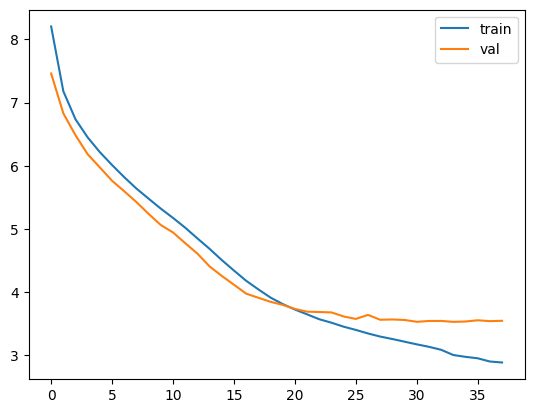

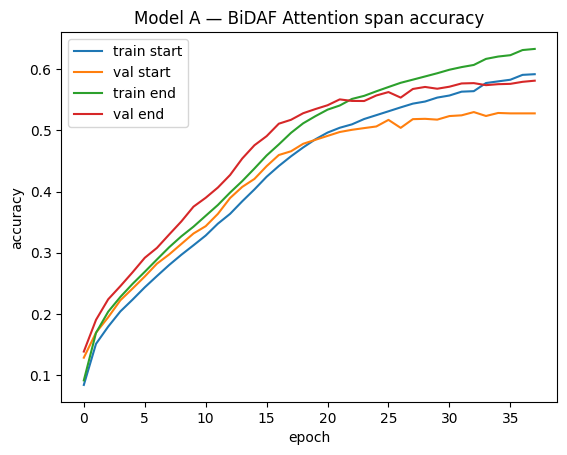

331/331 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step
Exact Match: 56.26
F1:          68.19


In [14]:
plot_graph(history.history, "Model A — BiDAF Attention span accuracy")


ad_df_grouped = apply_vocabulary(ad_df_grouped, word2idx)
ad_df_grouped["context_ids_pad"] = pad_sequences(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["question_ids_pad"] = pad_sequences(
    ad_df_grouped["question_ids"], MAX_QUESTION_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["context_mask"] = make_mask(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH
)

gold_answers = dict(zip(ad_df_grouped["question_id"], ad_df_grouped["text"]))
eval_df = ad_df_grouped  # predict on this directly

start_logits, end_logits = model.predict(
    {
        "question_ids": np.array(eval_df["question_ids_pad"].to_list(), dtype=np.int32),
        "context_ids": np.array(eval_df["context_ids_pad"].to_list(), dtype=np.int32),
        "context_mask": np.array(eval_df["context_mask"].to_list(), dtype=np.float32),
    },  # type: ignore
    batch_size=32,
)

em, f1, n = get_score(eval_df, gold_answers, start_logits, end_logits)

print(f"Exact Match: {100*em/n:.2f}")
print(f"F1:          {100*f1/n:.2f}")

## Model A: Single Attention

In [ ]:

# VOCAB_SIZE = t_embeddings.shape[0]  # or => len(word2idx)
# EMB_DIM = t_embeddings.shape[1]  # Embedding Dimensions matching GloVe
# HIDDEN = 128
# Q_LEN = MAX_QUESTION_LENGTH  # Padded question Length
# C_LEN = MAX_CONTEXT_LENGTH  # Padded context length

# # if OOM error then change to dtype=np.int32 to all below arrays.
# q_ids_arr = np.array(at_df["question_ids_pad"].to_list())
# c_ids_arr = np.array(at_df["context_ids_pad"].to_list())
# c_mask_arr = np.array(at_df["context_mask"].to_list(), dtype=np.float32)
# y_start_arr = np.array(at_df["start_token"].to_list())
# y_end_arr = np.array(at_df["end_token"].to_list())

# val_q_ids_arr = np.array(av_df["question_ids_pad"].to_list())
# val_c_ids_arr = np.array(av_df["context_ids_pad"].to_list())
# val_c_mask_arr = np.array(av_df["context_mask"].to_list(), dtype=np.float32)
# val_y_start_arr = np.array(av_df["start_token"].to_list())
# val_y_end_arr = np.array(av_df["end_token"].to_list())

def build_model(vocab_size, emb_dim, glove_matrix, q_len, c_len,
                hidden=96, dropout=0.4, l2=1e-4):
    reg = regularizers.l2(l2)

    q_ids = layers.Input(shape=(q_len,), dtype="int32", name="question_ids")
    c_ids = layers.Input(shape=(c_len,), dtype="int32", name="context_ids")
    c_mask_input = layers.Input(shape=(c_len,), dtype="float32", name="context_mask")

    # frozen GloVe embedding
    embedding = layers.Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[glove_matrix],
        mask_zero=True,
        trainable=False,
        name="glove_embeddings",
    )

    emb_drop = layers.SpatialDropout1D(dropout)
    q_emb = emb_drop(embedding(q_ids))
    c_emb = emb_drop(embedding(c_ids))

    q_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(q_emb)
    c_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(c_emb)
    q_enc = layers.SpatialDropout1D(dropout)(q_enc)
    c_enc = layers.SpatialDropout1D(dropout)(c_enc)

    # single context->question attention, replacing BiDAF.
    # query = context, value = question. Each context token gets a question-aware
    # vector. Output is 2*hidden wide (vs BiDAF's 8*hidden) -> far fewer params in
    # the modeling layer -> less overfitting. Masks from mask_zero mean padded
    # question tokens are automatically NOT attended to.
    q_aware = layers.Attention(dropout=dropout)([c_enc, q_enc])   # (B, C_LEN, 2*hidden)
    fused = layers.Concatenate()([c_enc, q_aware])                # (B, C_LEN, 4*hidden)

    # Modeling layer
    modeled = layers.Bidirectional(
        layers.LSTM(hidden, return_sequences=True,
                    kernel_regularizer=reg, recurrent_regularizer=reg)
    )(fused)
    modeled = layers.SpatialDropout1D(dropout)(modeled)

    # Two span heads start and end
    start_logits = layers.Dense(1, kernel_regularizer=reg)(modeled)
    end_logits   = layers.Dense(1, kernel_regularizer=reg)(modeled)
    start = layers.Flatten()(start_logits)
    end   = layers.Flatten()(end_logits)

    # Mask PAD positions before loss
    start = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="start")([start, c_mask_input])
    end   = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="end")([end, c_mask_input])

    return Model(inputs=[q_ids, c_ids, c_mask_input], outputs=[start, end])

model = build_model(VOCAB_SIZE, EMB_DIM, t_embeddings, Q_LEN, C_LEN,
                    hidden=128, dropout=0.2)

# Using AdamW as it adds decoupled weight decay (cleaner than L2 alone).
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss={
        "start": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "end":   tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    metrics={"start": "sparse_categorical_accuracy",
             "end":   "sparse_categorical_accuracy"},
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

history = model.fit(
    {
        "question_ids": q_ids_arr,
        "context_ids": c_ids_arr,
        "context_mask": c_mask_arr,
    },
    {
        "start": y_start_arr,
        "end": y_end_arr,
    },
    validation_data=( # type: ignore
        {"question_ids": val_q_ids_arr, "context_ids": val_c_ids_arr, "context_mask": val_c_mask_arr},
        {"start": val_y_start_arr, "end": val_y_end_arr},
    ),
    batch_size=64,
    epochs=21,
    callbacks=callbacks,
)

/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten_2' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten_3' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 209s 163ms/step - end_loss: 3.3468 - end_sparse_categorical_accuracy: 0.1781 - loss: 7.0349 - start_loss: 3.5838 - start_sparse_categorical_accuracy: 0.1602 - val_end_loss: 2.7635 - val_end_sparse_categorical_accuracy: 0.2807 - val_loss: 5.9001 - val_start_loss: 3.0184 - val_start_sparse_categorical_accuracy: 0.2480 - learning_rate: 0.0010
Epoch 2/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 209s 167ms/step - end_loss: 2.5767 - end_sparse_categorical_accuracy: 0.3312 - loss: 5.5094 - start_loss: 2.7851 - start_sparse_categorical_accuracy: 0.3039 - val_end_loss: 1.9727 - val_end_sparse_categorical_accuracy: 0.4746 - val_loss: 4.3168 - val_start_loss: 2.1741 - val_start_sparse_categorical_accuracy: 0.4290 - learning_rate: 0.0010
Epoch 3/35
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 162ms/step - end_loss: 2.0918 - end_sparse_categorical_accuracy: 0.4453 - loss: 4.5646 - start_loss: 2.2826 - start_sparse_categorical_accuracy: 0.4112 - val_end_loss: 1.7553 - val_end_

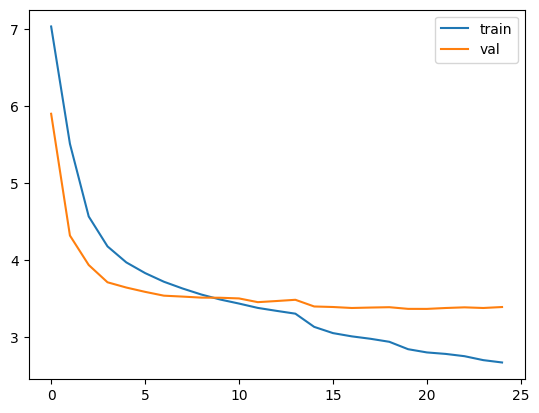

331/331 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step
Exact Match: 59.21
F1:          70.69


In [ ]:
plot_graph(history.history, "Model A — Single Attention span accuracy")


ad_df_grouped = apply_vocabulary(ad_df_grouped, word2idx)
ad_df_grouped["context_ids_pad"] = pad_sequences(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["question_ids_pad"] = pad_sequences(
    ad_df_grouped["question_ids"], MAX_QUESTION_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["context_mask"] = make_mask(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH
)

gold_answers = dict(zip(ad_df_grouped["question_id"], ad_df_grouped["text"]))
eval_df = ad_df_grouped  # predict on this directly

start_logits, end_logits = model.predict(
    {
        "question_ids": np.array(eval_df["question_ids_pad"].to_list(), dtype=np.int32),
        "context_ids": np.array(eval_df["context_ids_pad"].to_list(), dtype=np.int32),
        "context_mask": np.array(eval_df["context_mask"].to_list(), dtype=np.float32),
    },  # type: ignore
    batch_size=32,
)

em, f1, n = get_score(eval_df, gold_answers, start_logits, end_logits)

print(f"Exact Match: {100*em/n:.2f}")
print(f"F1:          {100*f1/n:.2f}")

# Model A: Single Attention Hyperparameter Tuning

In [31]:
import optuna

N = 25000
sub = {"question_ids": q_ids_arr[:N], "context_ids": c_ids_arr[:N], "context_mask": c_mask_arr[:N]}
sub_y = {"start": y_start_arr[:N], "end": y_end_arr[:N]}
val_x = {"question_ids": val_q_ids_arr, "context_ids": val_c_ids_arr, "context_mask": val_c_mask_arr}
val_y = {"start": val_y_start_arr, "end": val_y_end_arr}

def objective(trial):
    hidden  = trial.suggest_categorical("hidden", [128, 256])
    dropout = trial.suggest_float("dropout", 0.3, 0.4)
    lr      = trial.suggest_float("lr", 1e-3, 3e-3, log=True)   # log scale for LR

    tf.keras.backend.clear_session()                            # free GPU between trials
    model = build_model(VOCAB_SIZE, EMB_DIM, t_embeddings, Q_LEN, C_LEN,
                        hidden=hidden, dropout=dropout)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={"start": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              "end":   tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
        metrics={"start": "sparse_categorical_accuracy", "end": "sparse_categorical_accuracy"},
    )
    hist = model.fit(
        sub, sub_y, validation_data=(val_x, val_y),
        epochs=8, batch_size=64, verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    )
    return min(hist.history["val_loss"])        # objective: lowest val_loss

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=15)

print("Best params:", study.best_params)
print("Best val_loss:", study.best_value)

[I 2026-06-30 04:28:56,562] A new study created in memory with name: no-name-36383103-0862-4ec2-b490-3a2d8ef4c81b
/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten_1' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
[I 2026-06-30 04:36:48,743] Trial 0 finished with value: 6.303150653839111 and parameters: {'hidden': 256, 'dropout': 0.3731993941811405, 'lr': 0.00193033500862933}. Best is trial 0 with value: 6.303150653839111.
[I 2026-06-30 04:44:4

Best params: {'hidden': 128, 'dropout': 0.3181824967207101, 'lr': 0.00122322455316012}
Best val_loss: 5.553293228149414


In [11]:
VOCAB_SIZE = t_embeddings.shape[0]  # or => len(word2idx)
EMB_DIM = t_embeddings.shape[1]  # Embedding Dimensions matching GloVe
HIDDEN = 128
Q_LEN = MAX_QUESTION_LENGTH  # Padded question Length
C_LEN = MAX_CONTEXT_LENGTH  # Padded context length

# if OOM error then change to dtype=np.int32 to all below arrays.
q_ids_arr = np.array(at_df["question_ids_pad"].to_list())
c_ids_arr = np.array(at_df["context_ids_pad"].to_list())
c_mask_arr = np.array(at_df["context_mask"].to_list(), dtype=np.float32)
y_start_arr = np.array(at_df["start_token"].to_list())
y_end_arr = np.array(at_df["end_token"].to_list())

val_q_ids_arr = np.array(av_df["question_ids_pad"].to_list())
val_c_ids_arr = np.array(av_df["context_ids_pad"].to_list())
val_c_mask_arr = np.array(av_df["context_mask"].to_list(), dtype=np.float32)
val_y_start_arr = np.array(av_df["start_token"].to_list())
val_y_end_arr = np.array(av_df["end_token"].to_list())

def build_model(vocab_size, emb_dim, glove_matrix, q_len, c_len,
                hidden=96, dropout=0.4, l2=1e-4):
    reg = regularizers.l2(l2)

    q_ids = layers.Input(shape=(q_len,), dtype="int32", name="question_ids")
    c_ids = layers.Input(shape=(c_len,), dtype="int32", name="context_ids")
    c_mask_input = layers.Input(shape=(c_len,), dtype="float32", name="context_mask")

    # frozen GloVe embedding
    embedding = layers.Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[glove_matrix],
        mask_zero=True,
        trainable=False,
        name="glove_embeddings",
    )

    emb_drop = layers.SpatialDropout1D(dropout)
    q_emb = emb_drop(embedding(q_ids))
    c_emb = emb_drop(embedding(c_ids))

    q_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(q_emb)
    c_enc = layers.Bidirectional(layers.LSTM(hidden, return_sequences=True))(c_emb)
    q_enc = layers.SpatialDropout1D(dropout)(q_enc)
    c_enc = layers.SpatialDropout1D(dropout)(c_enc)

    # single context->question attention, replacing BiDAF.
    # query = context, value = question. Each context token gets a question-aware
    # vector. Output is 2*hidden wide (vs BiDAF's 8*hidden) -> far fewer params in
    # the modeling layer -> less overfitting. Masks from mask_zero mean padded
    # question tokens are automatically NOT attended to.
    q_aware = layers.Attention(dropout=dropout)([c_enc, q_enc])   # (B, C_LEN, 2*hidden)
    fused = layers.Concatenate()([c_enc, q_aware])                # (B, C_LEN, 4*hidden)

    # Modeling layer
    modeled = layers.Bidirectional(
        layers.LSTM(hidden, return_sequences=True,
                    kernel_regularizer=reg, recurrent_regularizer=reg)
    )(fused)
    modeled = layers.SpatialDropout1D(dropout)(modeled)

    # Two span heads start and end
    start_logits = layers.Dense(1, kernel_regularizer=reg)(modeled)
    end_logits   = layers.Dense(1, kernel_regularizer=reg)(modeled)
    start = layers.Flatten()(start_logits)
    end   = layers.Flatten()(end_logits)

    # Mask PAD positions before loss
    start = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="start")([start, c_mask_input])
    end   = layers.Lambda(lambda x: x[0] - (1.0 - x[1]) * 1e9, name="end")([end, c_mask_input])

    return Model(inputs=[q_ids, c_ids, c_mask_input], outputs=[start, end])

model = build_model(VOCAB_SIZE, EMB_DIM, t_embeddings, Q_LEN, C_LEN,
                    hidden=128, dropout=0.3181824967207101)

# 1. Best params: {'hidden': 128, 'dropout': 0.27029763351931, 'lr': 0.0008329549660292198}
# 2. Best params: {'hidden': 128, 'dropout': 0.3181824967207101, 'lr': 0.00122322455316012}

# Using AdamW as it adds decoupled weight decay (cleaner than L2 alone).
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.00122322455316012, weight_decay=1e-4),
    loss={
        "start": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "end":   tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    metrics={"start": "sparse_categorical_accuracy",
             "end":   "sparse_categorical_accuracy"},
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

history = model.fit(
    {
        "question_ids": q_ids_arr,
        "context_ids": c_ids_arr,
        "context_mask": c_mask_arr,
    },
    {
        "start": y_start_arr,
        "end": y_end_arr,
    },
    validation_data=( # type: ignore
        {"question_ids": val_q_ids_arr, "context_ids": val_c_ids_arr, "context_mask": val_c_mask_arr},
        {"start": val_y_start_arr, "end": val_y_end_arr},
    ),
    batch_size=64,
    epochs=21,
    callbacks=callbacks,
)

W0000 00:00:1782799147.821917  302940 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1782799147.830319  302940 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1782799148.284907  302940 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
/home/nix/.mv_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers

Epoch 1/21


I0000 00:00:1782799155.847794  303819 cuda_dnn.cc:461] Loaded cuDNN version 91002


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 208s 161ms/step - end_loss: 3.5033 - end_sparse_categorical_accuracy: 0.1517 - loss: 7.3729 - start_loss: 3.7557 - start_sparse_categorical_accuracy: 0.1367 - val_end_loss: 3.0101 - val_end_sparse_categorical_accuracy: 0.2166 - val_loss: 6.4030 - val_start_loss: 3.2611 - val_start_sparse_categorical_accuracy: 0.2050 - learning_rate: 0.0012
Epoch 2/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 214s 171ms/step - end_loss: 2.9911 - end_sparse_categorical_accuracy: 0.2304 - loss: 6.3727 - start_loss: 3.2224 - start_sparse_categorical_accuracy: 0.2111 - val_end_loss: 2.7298 - val_end_sparse_categorical_accuracy: 0.2729 - val_loss: 5.8800 - val_start_loss: 2.9743 - val_start_sparse_categorical_accuracy: 0.2501 - learning_rate: 0.0012
Epoch 3/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 241s 192ms/step - end_loss: 2.7970 - end_sparse_categorical_accuracy: 0.2666 - loss: 6.0082 - start_loss: 3.0155 - start_sparse_categorical_accuracy: 0.2448 - val_end_loss: 2.5779 - val_end_sparse_cate

In [12]:
# Re ran the training i.e continue 21 epoch onwards, since it's still being trained.

history = model.fit(
    {
        "question_ids": q_ids_arr,
        "context_ids": c_ids_arr,
        "context_mask": c_mask_arr,
    },
    {
        "start": y_start_arr,
        "end": y_end_arr,
    },
    validation_data=( # type: ignore
        {"question_ids": val_q_ids_arr, "context_ids": val_c_ids_arr, "context_mask": val_c_mask_arr},
        {"start": val_y_start_arr, "end": val_y_end_arr},
    ),
    batch_size=64,
    epochs=40,
    callbacks=callbacks,
)

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 165s 132ms/step - end_loss: 2.0058 - end_sparse_categorical_accuracy: 0.4475 - loss: 4.5801 - start_loss: 2.1867 - start_sparse_categorical_accuracy: 0.4136 - val_end_loss: 1.9237 - val_end_sparse_categorical_accuracy: 0.4700 - val_loss: 4.4107 - val_start_loss: 2.1057 - val_start_sparse_categorical_accuracy: 0.4327 - learning_rate: 0.0012
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 166s 133ms/step - end_loss: 1.9906 - end_sparse_categorical_accuracy: 0.4517 - loss: 4.5535 - start_loss: 2.1717 - start_sparse_categorical_accuracy: 0.4176 - val_end_loss: 1.9220 - val_end_sparse_categorical_accuracy: 0.4716 - val_loss: 4.4258 - val_start_loss: 2.1185 - val_start_sparse_categorical_accuracy: 0.4290 - learning_rate: 0.0012
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - end_loss: 1.9666 - end_sparse_categorical_accuracy: 0.4564 - loss: 4.5078 - start_loss: 2.1489 - start_sparse_categorical_accuracy: 0.4224
Epoch 3: ReduceLROnPlateau reducing

In [24]:
# plot_graph(history, "Model A — Single Attention span accuracy")


ad_df_grouped = apply_vocabulary(ad_df_grouped, word2idx)
ad_df_grouped["context_ids_pad"] = pad_sequences(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["question_ids_pad"] = pad_sequences(
    ad_df_grouped["question_ids"], MAX_QUESTION_LENGTH, word2idx["<PAD>"]
)
ad_df_grouped["context_mask"] = make_mask(
    ad_df_grouped["context_ids"], MAX_CONTEXT_LENGTH
)

gold_answers = dict(zip(ad_df_grouped["question_id"], ad_df_grouped["text"]))
eval_df = ad_df_grouped  # predict on this directly

start_logits, end_logits = model.predict(
    {
        "question_ids": np.array(eval_df["question_ids_pad"].to_list(), dtype=np.int32),
        "context_ids": np.array(eval_df["context_ids_pad"].to_list(), dtype=np.int32),
        "context_mask": np.array(eval_df["context_mask"].to_list(), dtype=np.float32),
    },  # type: ignore
    batch_size=32,
)

em, f1, n = get_score(eval_df, gold_answers, start_logits, end_logits)

print(f"Exact Match: {100*em/n:.2f}")
print(f"F1:          {100*f1/n:.2f}")

331/331 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step
Exact Match: 58.27
F1:          69.72


### Model B Tokenization, Encodings
### Train Data and Dev Data

In [15]:
def get_tokenizer():
    return AutoTokenizer.from_pretrained("distilbert-base-uncased", use_fast=True)


def generate_encodings(df):
    b_tokenizer = get_tokenizer()

    return b_tokenizer(
        df["question"].tolist(),
        df["context"].tolist(),
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )


def compact_encode(df):
    enc = generate_encodings(df)
    enc = map_answer_to_positions(enc, df)

    out = {
        "input_ids": np.asarray(enc["input_ids"], dtype=np.int32),
        "attention_mask": np.asarray(enc["attention_mask"], dtype=np.int32),
        "start_positions": np.asarray(enc["start_positions"], dtype=np.int32),
        "end_positions": np.asarray(enc["end_positions"], dtype=np.int32),
    }
    del enc
    gc.collect()

    return out


# Generate Encodings for Train Dataset
bt_enc = compact_encode(train_df)

# one row per question
dev_unique = (
    dev_df.drop_duplicates(["question_id", "text"])
    .groupby("question_id", as_index=False)
    .agg(
        {
            "question": "first",
            "context": "first",
            "answer_start": "first",
            "answer_end": "first",
            "text": list,
        }
    )
)

# Generate Encodings for Dev Dataset
bd_enc = generate_encodings(dev_unique)
bd_enc = map_answer_to_positions(bd_enc, dev_unique)

# Model B: Train & Evaluate

In [ ]:

class SquadDataset(Dataset):
    """Wraps your numpy dict. PyTorch wants int64, so cast per item."""
    def __init__(self, enc):
        self.enc = enc
    def __len__(self):
        return len(self.enc["input_ids"])
    def __getitem__(self, i):
        return {
            "input_ids":      torch.tensor(self.enc["input_ids"][i],      dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][i], dtype=torch.long),
            "start_positions": torch.tensor(int(self.enc["start_positions"][i]), dtype=torch.long),
            "end_positions":   torch.tensor(int(self.enc["end_positions"][i]),   dtype=torch.long),
        }

train_dataset = SquadDataset(bt_enc)          # your existing numpy train encodings

model = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-uncased")  # adds the QA head

use_cuda = torch.cuda.is_available()
args = TrainingArguments(
    output_dir="modelB_distilbert_squad",
    per_device_train_batch_size=16,           # drop to 8 if OOM
    num_train_epochs=2,                       # 2–3 is standard
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,                         # replaces create_optimizer's warmup
    bf16=use_cuda,                            # Blackwell does bf16 well -> faster, less VRAM
    logging_steps=100,
    save_strategy="epoch",
    report_to="none",                         # no wandb prompt
)

trainer = Trainer(model=model, args=args, train_dataset=train_dataset)
trainer.train()

trainer.save_model("modelB_distilbert_squad")
get_tokenizer().save_pretrained("modelB_distilbert_squad")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
qa_outputs.bias         | MISSING    | 
qa_outputs.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
100,5.876484
200,5.190244
300,4.125452
400,3.721431
500,3.398043
600,2.807708
700,2.514018
800,2.391756
900,2.254627
1000,2.042848


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

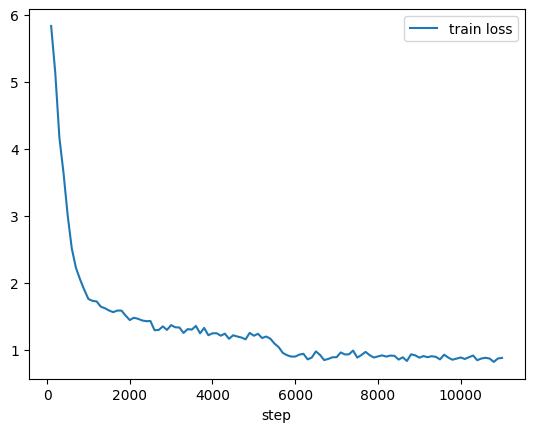

Exact Match: 77.43
F1:          85.81


In [9]:
from evaluate.validations import (compute_em, compute_f1, max_over_golds, MAX_ANSWER_LEN)

logs   = trainer.state.log_history
steps  = [l["step"] for l in logs if "loss" in l]
losses = [l["loss"] for l in logs if "loss" in l]
plt.plot(steps, losses, label="train loss")
plt.xlabel("step"); plt.legend(); plt.show()


N_BEST = 20

# 1) Unique-question dev frame + golds. dev_unique (from clean_dev_data) already
#    has one row per question_id with text = [list of golds]. Reuse it:
# dev_unique = dev_unique.reset_index(drop=True)
gold_answers = dict(zip(dev_unique["question_id"], dev_unique["text"]))

eval_enc = bd_enc                  # BatchEncoding: sequence_ids + offsets

model.eval()
device = next(model.parameters()).device
ids_all  = np.asarray(bd_enc["input_ids"],      dtype=np.int64)
mask_all = np.asarray(bd_enc["attention_mask"], dtype=np.int64)

starts, ends = [], []
with torch.no_grad():
    for i in range(0, len(ids_all), 64):
        out = model(input_ids=torch.tensor(ids_all[i:i+64],  device=device),
                    attention_mask=torch.tensor(mask_all[i:i+64], device=device))
        starts.append(out.start_logits.float().cpu().numpy())
        ends.append(out.end_logits.float().cpu().numpy())

start_logits = np.concatenate(starts)
end_logits   = np.concatenate(ends)

# 4) Best span per question, aggregated across its overflow windows.
sample_map = bd_enc["overflow_to_sample_mapping"]
offset_map = bd_enc["offset_mapping"]
best = {}   # qid -> (score, text)

for i in range(len(start_logits)):
    sidx    = sample_map[i]
    qid     = dev_unique.iloc[sidx]["question_id"]
    context = dev_unique.iloc[sidx]["context"]
    seq_ids = bd_enc.sequence_ids(i)
    offsets = offset_map[i]
    s_log, e_log = start_logits[i], end_logits[i]

    for s in np.argsort(s_log)[-N_BEST:]:
        if seq_ids[s] != 1:                       # context tokens only
            continue
        for e in np.argsort(e_log)[-N_BEST:]:
            if seq_ids[e] != 1 or e < s or (e - s + 1) > MAX_ANSWER_LEN:
                continue
            score = s_log[s] + e_log[e]
            if qid not in best or score > best[qid][0]:
                best[qid] = (score, context[offsets[s][0]: offsets[e][1]])

# 5) Score with the SAME functions as Model A.
em = f1 = 0.0
for qid, golds in gold_answers.items():
    pred_text = best.get(qid, (0.0, ""))[1]
    em += max_over_golds(compute_em, pred_text, golds)
    f1 += max_over_golds(compute_f1, pred_text, golds)
n = len(gold_answers)
print(f"Exact Match: {100*em/n:.2f}")
print(f"F1:          {100*f1/n:.2f}")

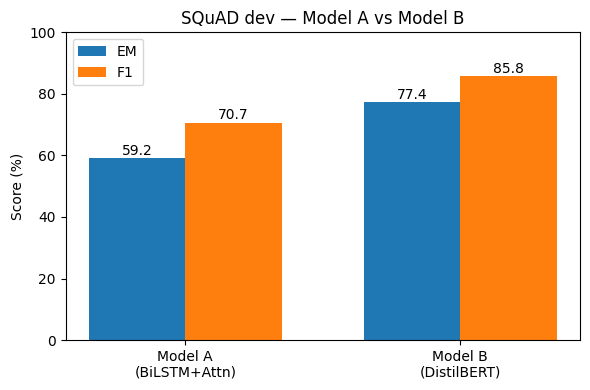

In [ ]:
from evaluate.validations import compute_em, compute_f1, max_over_golds, MAX_ANSWER_LEN

# Comparison
models = ["Model A\n(BiLSTM+Attn)", "Model B\n(DistilBERT)"]
em = [59.21, 77.43]      # <- plug in your final Model A numbers
f1 = [70.69, 85.81]

x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, em, w, label="EM")
ax.bar(x + w/2, f1, w, label="F1")
for i in range(len(models)):
    ax.text(x[i]-w/2, em[i]+1, f"{em[i]:.1f}", ha="center")
    ax.text(x[i]+w/2, f1[i]+1, f"{f1[i]:.1f}", ha="center")
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylabel("Score (%)")
ax.set_ylim(0, 100); ax.set_title("SQuAD dev — Model A vs Model B"); ax.legend()
plt.tight_layout(); plt.show()
